<a href="https://colab.research.google.com/github/hwasun-zip/Behind-the-Coupon/blob/main/notebooks/01_data_and_engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
# 드라이브 연결
from google.colab import drive
drive.mount('/content/drive')

import os
BASE = '/content/drive/MyDrive/Behind-the-Coupon'
for sub in ['data', 'notebooks', 'output']:
    os.makedirs(f'{BASE}/{sub}', exist_ok=True)
print(BASE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Behind-the-Coupon


In [25]:
# 라이브러리 설치
!pip install -q yfinance pykrx koreanize-matplotlib
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import yfinance as yf
import koreanize_matplotlib   # 그래프 한글 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# yfinance: 야후 파이낸스에서 해외 지수 받는 용도
# pykrx: 한국거래소 데이터용. KOSPI200이 야후에서 안 받아지면 대신 씀
# koreanize-matplotlib: 코랩 그래프에서 한글이 네모로 깨지는 거 방지

In [26]:
# 지수 데이터 수집
!pip install -q finance-datareader
import FinanceDataReader as fdr

TICKERS = {'KOSPI200': '^KS200', 'SPX': '^GSPC', 'SX5E': '^STOXX50E',
           'NKY': '^N225', 'HSCEI': '^HSCE'}
CACHE = f'{BASE}/data/index_close.csv'
START = '2004-01-01'

def to_series(x):
    """yfinance 결과를 항상 한 줄짜리 시계열(Series)로 맞춰줌"""
    if isinstance(x, pd.DataFrame):
        x = x.iloc[:, 0]
    return x

def get_kospi200():
    """KOSPI200은 야후가 불안정해서 대체 경로를 순서대로 시도"""
    try:
        s = fdr.DataReader('KS200', START)['Close']
        if len(s) > 1000:
            return s, 'FinanceDataReader'
    except Exception as e:
        print('  FDR 실패:', e)
    try:
        from pykrx import stock
        df = stock.get_index_ohlcv(START.replace('-', ''),
                                   pd.Timestamp.today().strftime('%Y%m%d'), '1028')
        return df['종가'], 'pykrx'
    except Exception as e:
        print('  pykrx 실패:', e)
    return None, None

def download_all():
    out = {}
    for name, tk in TICKERS.items():
        s = to_series(yf.download(tk, start=START, auto_adjust=False, progress=False)['Close'])
        src = 'yfinance'
        if name == 'KOSPI200' and len(s) < 1000:
            s, src = get_kospi200()
            if s is None:
                print('KOSPI200 수집 실패 → 일단 제외하고 진행')
                continue
        out[name] = s
        print(f'{name:9s} {s.index.min().date()} ~ {s.index.max().date()}  {len(s):,}건  ({src})')
    return pd.DataFrame(out)

if os.path.exists(CACHE):
    raw = pd.read_csv(CACHE, index_col=0, parse_dates=True)
else:
    raw = download_all()
    raw.to_csv(CACHE)
raw.tail()

,KOSPI200,SPX,SX5E,NKY,HSCEI
Date,,,,,
2026-09-28,NaN,7683.689941,6301.279785,65877.617188,8216.839844
2026-09-29,NaN,7670.839844,6320.259766,65481.269531,8178.810059
2026-09-30,NaN,7651.540039,6269.020020,66753.718750,8220.080078
2026-10-01,NaN,7666.450195,6175.450195,68956.718750,NaN
2026-10-02,NaN,NaN,NaN,68390.367188,8006.850098


지수별 실제 시작일
KOSPI200   2004-01-02
SPX        2004-01-02
SX5E       2007-03-30
NKY        2004-01-05
HSCEI      2004-01-02
dtype: datetime64[ns]

결측 비율 (ffill 전)
KOSPI200    0.053
SPX         0.033
SX5E        0.174
NKY         0.060
HSCEI       0.053
dtype: float64


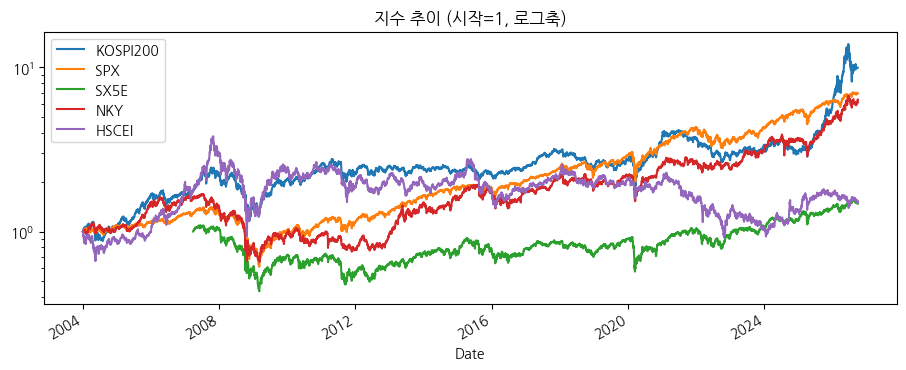

In [27]:
# 데이터 체크
px = raw.sort_index().ffill()
print('지수별 실제 시작일')
print(px.notna().idxmax())
print('\n결측 비율 (ffill 전)')
print(raw.isna().mean().round(3))

(px / px.bfill().iloc[0]).plot(figsize=(11, 4), logy=True, title='지수 추이 (시작=1, 로그축)')
plt.show()

발행일 H지수     12,229
녹인 50% 선      6,114
3년 내 최저점    4,939  → 발행일 대비 40%
만기일 H지수     5,559  → 발행일 대비 45%


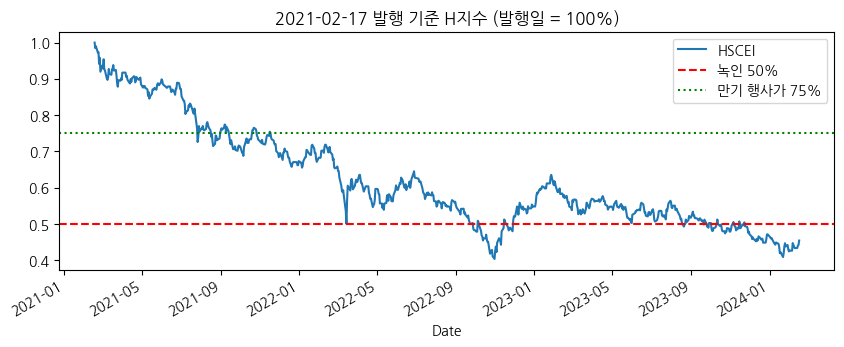

In [28]:
h = px['HSCEI']
t0 = pd.Timestamp('2021-02-17')
base = h.asof(t0)                                  # 발행일 종가 = 100%
low = h.loc[t0:t0 + pd.DateOffset(years=3)].min()  # 3년 안 최저점
mat = h.asof(t0 + pd.DateOffset(years=3))          # 만기일 종가

print(f'발행일 H지수     {base:,.0f}')
print(f'녹인 50% 선      {base*0.5:,.0f}')
print(f'3년 내 최저점    {low:,.0f}  → 발행일 대비 {low/base:.0%}')
print(f'만기일 H지수     {mat:,.0f}  → 발행일 대비 {mat/base:.0%}')

(h.loc[t0:t0 + pd.DateOffset(years=3)] / base).plot(figsize=(10, 3.5),
    title='2021-02-17 발행 기준 H지수 (발행일 = 100%)')
plt.axhline(0.5, ls='--', c='r', label='녹인 50%')
plt.axhline(0.75, ls=':', c='g', label='만기 행사가 75%')
plt.legend(); plt.show()

In [29]:
# 상환 엔진
def simulate_stepdown(prices, assets, strikes=(0.90, 0.90, 0.85, 0.85, 0.80, 0.75),
                      ki=0.50, obs_months=6, start=None, end=None):
    """매 거래일 ELS가 하나씩 발행됐다고 가정하고 각각의 결과를 계산"""
    px = prices[assets].dropna()
    dates = px.index
    vals = px.values
    n_obs = len(strikes)

    issue_dates = dates
    if start is not None:
        issue_dates = issue_dates[issue_dates >= pd.Timestamp(start)]
    if end is not None:
        issue_dates = issue_dates[issue_dates <= pd.Timestamp(end)]

    rows = []
    for t0 in issue_dates:
        # ① 평가일 6개 만들기
        obs_dates = [t0 + pd.DateOffset(months=obs_months * (k + 1)) for k in range(n_obs)]
        if obs_dates[-1] > dates[-1]:
            break   # 만기가 아직 안 온 ELS는 제외

        i0 = dates.get_loc(t0)
        obs_idx = dates.searchsorted(obs_dates)
        base = vals[i0]

        # ② 6개월마다 조기상환 평가
        result = None
        end_idx = obs_idx[-1]                      # 기본값: 만기일
        for k, (oi, s) in enumerate(zip(obs_idx, strikes)):
            worst = (vals[oi] / base).min()
            if worst >= s:
                kind = '조기상환' if k < n_obs - 1 else '만기상환(행사가)'
                result = (kind, k + 1, 1.0)
                end_idx = oi                       # 상환된 날까지만 보유
                break

        # ③ 실제 보유 기간 동안의 최악 지수 경로 (수정된 부분)
        worst_path = (vals[i0:end_idx + 1] / base).min(axis=1)

        # ④ 끝까지 상환 못 했으면 만기 판정
        if result is None:
            ki_hit = True if ki is None else worst_path.min() < ki
            worst_final = (vals[obs_idx[-1]] / base).min()
            if not ki_hit:
                result = ('만기상환(원금)', n_obs, 1.0)
            else:
                result = ('손실', n_obs, worst_final)

        kind, k, principal = result
        rows.append({
            'issue_date': t0,
            'outcome': kind,
            'redeem_step': k,
            'years': k * obs_months / 12,
            'principal': principal,
            'coupon_years': k * obs_months / 12 if kind in ('조기상환', '만기상환(행사가)') else 0.0,
            'ki_touch': ki is not None and worst_path.min() < ki,
            'worst_min': worst_path.min(),
        })
    return pd.DataFrame(rows)

In [30]:
# 엔진 테스트
test = simulate_stepdown(px, ['SPX', 'SX5E', 'HSCEI'],  )
print(test['outcome'].value_counts())
test.head(10)

outcome
조기상환         3755
손실            274
만기상환(행사가)     223
만기상환(원금)       44
Name: count, dtype: int64


,issue_date,outcome,redeem_step,years,principal,coupon_years,ki_touch,worst_min
0,2007-03-30,조기상환,1,0.5,1.0,0.5,False,0.971610
1,2007-04-02,조기상환,1,0.5,1.0,0.5,False,0.969634
2,2007-04-03,조기상환,1,0.5,1.0,0.5,False,0.956675
3,2007-04-04,조기상환,1,0.5,1.0,0.5,False,0.953189
4,2007-04-05,조기상환,1,0.5,1.0,0.5,False,0.951022
5,2007-04-06,조기상환,1,0.5,1.0,0.5,False,0.951022
6,2007-04-09,조기상환,1,0.5,1.0,0.5,False,0.951022
7,2007-04-10,조기상환,1,0.5,1.0,0.5,False,0.944405
8,2007-04-11,조기상환,1,0.5,1.0,0.5,False,0.946224
9,2007-04-12,조기상환,1,0.5,1.0,0.5,False,0.949138


In [31]:
# 쿠폰 함수
def apply_coupon(res, coupon):
    """연 쿠폰을 대입해 상환금액과 연환산 수익률 계산"""
    payoff = res['principal'] + coupon * res['coupon_years']   # 돌려받은 돈 (원금=1)
    ann = payoff ** (1 / res['years']) - 1                      # 연환산 수익률
    return payoff, ann


def required_coupon(res, benchmark=0.03, lo=0.0, hi=0.50, tol=1e-5):
    """평균 연환산 수익률이 benchmark와 같아지는 최소 쿠폰 = 필요 쿠폰"""
    f = lambda c: apply_coupon(res, c)[1].mean() - benchmark
    if f(hi) < 0:
        return np.nan        # 쿠폰 50%를 줘도 안 되는 구조
    if f(lo) >= 0:
        return 0.0
    while hi - lo > tol:     # 이분법: 범위를 반씩 좁혀가며 정답 찾기
        mid = (lo + hi) / 2
        lo, hi = (mid, hi) if f(mid) < 0 else (lo, mid)
    return hi


def summarize(res, coupon=None):
    """결과 표를 핵심 지표 한 줄로 요약"""
    loss = res['outcome'] == '손실'
    out = {
        '발행건수': len(res),
        '조기상환율': (res['outcome'] == '조기상환').mean(),
        '1차상환율': (res['redeem_step'] == 1).mean(),
        '평균보유(년)': res['years'].mean(),
        '녹인터치율': res['ki_touch'].mean(),
        '손실확률': loss.mean(),
        '손실시평균손실률': 1 - res.loc[loss, 'principal'].mean() if loss.any() else 0.0,
    }
    if coupon is not None:
        out['연환산수익률(평균)'] = apply_coupon(res, coupon)[1].mean()
    return pd.Series(out)

In [32]:
# 전체 기간 실행
STRUCT = dict(strikes=(0.90, 0.90, 0.85, 0.85, 0.80, 0.75), ki=0.50)
COMBO = ['SPX', 'SX5E', 'HSCEI']
RF = 0.03    # 무위험 금리 임시값 (나중에 국고채 금리로 교체)

res = simulate_stepdown(px, COMBO, **STRUCT)
print(f"발행 기간: {res['issue_date'].min().date()} ~ {res['issue_date'].max().date()}")
print(f"필요 쿠폰: 연 {required_coupon(res, RF):.2%}\n")

compare = pd.DataFrame({
    '전체 기간': summarize(res, coupon=0.06),
    '2021년 1분기': summarize(test, coupon=0.06),
})
compare.round(3)

발행 기간: 2007-03-30 ~ 2023-10-02
필요 쿠폰: 연 4.31%



,전체 기간,2021년 1분기
발행건수,4296.000,4296.000
조기상환율,0.874,0.874
1차상환율,0.632,0.632
평균보유(년),1.048,1.048
녹인터치율,0.099,0.099
손실확률,0.064,0.064
손실시평균손실률,0.399,0.399
연환산수익률(평균),0.046,0.046


In [33]:
# 마무리(저장)
res.to_csv(f'{BASE}/output/01_base_SPX_SX5E_HSCEI.csv', index=False)
compare.round(4).to_csv(f'{BASE}/output/01_compare_full_vs_2021Q1.csv')
print('저장 완료')

저장 완료


In [34]:
# 엔진 저장
import inspect
os.makedirs(f'{BASE}/src', exist_ok=True)

header = 'import numpy as np\nimport pandas as pd\n\n\n'
funcs = [simulate_stepdown, apply_coupon, required_coupon, summarize]
code = header + '\n\n'.join(inspect.getsource(f) for f in funcs)

with open(f'{BASE}/src/els_engine.py', 'w') as f:
    f.write(code)
print('엔진 저장 완료:', f'{BASE}/src/els_engine.py')

엔진 저장 완료: /content/drive/MyDrive/Behind-the-Coupon/src/els_engine.py
